In [1]:
import pandas as pd
import numpy as np
import os
import optuna
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CURRENT_DIR = os.getcwd()
DATA_PATH = os.path.join(CURRENT_DIR, '..', 'data')
PROCESSED_DATA_PATH = os.path.join(DATA_PATH, 'processed')

train_df = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, 'movie_train.csv'))
test_df = pd.read_csv(os.path.join(PROCESSED_DATA_PATH, 'movie_test.csv'))

X_train = train_df.drop(columns=['profitable'], errors='ignore')
y_train = train_df['profitable']

X_test = test_df.drop(columns=['profitable'], errors='ignore')
y_test = test_df['profitable']

print(f"Kích thước X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Kích thước X_test : {X_test.shape}, y_test : {y_test.shape}")

Kích thước X_train: (1774, 52), y_train: (1774,)
Kích thước X_test : (444, 52), y_test : (444,)


In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def objective_lgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 200),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 7, 15),
        'max_depth':         trial.suggest_int('max_depth', 3, 5),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 60),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 1.0, log=True),
        'random_state': SEED,
        'verbose': -1
    }
    model = lgb.LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 200),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 10),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 1.0, log=True),
        'eval_metric': 'auc',
        'random_state': SEED
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(objective_lgb, n_trials=20)

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=20)

print(f"LGBM - Best CV AUC : {study_lgb.best_value:.4f}")
print(study_lgb.best_params)
print(f"XGB  - Best CV AUC : {study_xgb.best_value:.4f}")
print(study_xgb.best_params)

LGBM - Best CV AUC : 0.7524
{'n_estimators': 175, 'learning_rate': 0.07038298798597942, 'num_leaves': 8, 'max_depth': 3, 'min_child_samples': 39, 'subsample': 0.7217345110404302, 'colsample_bytree': 0.7106619614159261, 'reg_alpha': 0.0031381149231882134, 'reg_lambda': 0.009173826786868056}
XGB  - Best CV AUC : 0.7551
{'n_estimators': 152, 'learning_rate': 0.07666670818579745, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.8864302356876141, 'colsample_bytree': 0.6681845114128452, 'reg_alpha': 0.014410389498685642, 'reg_lambda': 0.006948015830344293}


In [3]:
best_lgb = lgb.LGBMClassifier(**study_lgb.best_params, random_state=SEED, verbose=-1)
best_xgb = xgb.XGBClassifier(**study_xgb.best_params, random_state=SEED, eval_metric='auc')

best_lgb.fit(X_train, y_train)
best_xgb.fit(X_train, y_train)

def evaluate_model_full(model, model_name, X_train, y_train, X_test, y_test):
    print(f"ĐÁNH GIÁ MÔ HÌNH: {model_name}")
    
    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    print("[TẬP TRAIN]")
    print(f"- ROC AUC : {roc_auc_score(y_train, y_train_proba):.4f}")
    print(f"- Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
    print("\nChi tiết từng nhãn (Train):")
    print(classification_report(y_train, y_train_pred, digits=4))
    
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    print("[TẬP TEST]")
    print(f"- ROC AUC : {roc_auc_score(y_test, y_test_proba):.4f}")
    print(f"- Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
    print("\nChi tiết từng nhãn (Test):")
    print(classification_report(y_test, y_test_pred, digits=4))
    
    return y_test_pred, y_test_proba

lgb_pred, lgb_proba = evaluate_model_full(best_lgb, "LightGBM", X_train, y_train, X_test, y_test)
xgb_pred, xgb_proba = evaluate_model_full(best_xgb, "XGBoost", X_train, y_train, X_test, y_test)

ĐÁNH GIÁ MÔ HÌNH: LightGBM
[TẬP TRAIN]
- ROC AUC : 0.8886
- Accuracy: 0.8157

Chi tiết từng nhãn (Train):
              precision    recall  f1-score   support

           0     0.8104    0.9090    0.8569      1077
           1     0.8269    0.6714    0.7411       697

    accuracy                         0.8157      1774
   macro avg     0.8186    0.7902    0.7990      1774
weighted avg     0.8169    0.8157    0.8114      1774

[TẬP TEST]
- ROC AUC : 0.7162
- Accuracy: 0.7005

Chi tiết từng nhãn (Test):
              precision    recall  f1-score   support

           0     0.7103    0.8507    0.7742       268
           1     0.6748    0.4716    0.5552       176

    accuracy                         0.7005       444
   macro avg     0.6925    0.6612    0.6647       444
weighted avg     0.6962    0.7005    0.6874       444

ĐÁNH GIÁ MÔ HÌNH: XGBoost
[TẬP TRAIN]
- ROC AUC : 0.8781
- Accuracy: 0.8033

Chi tiết từng nhãn (Train):
              precision    recall  f1-score   support

   

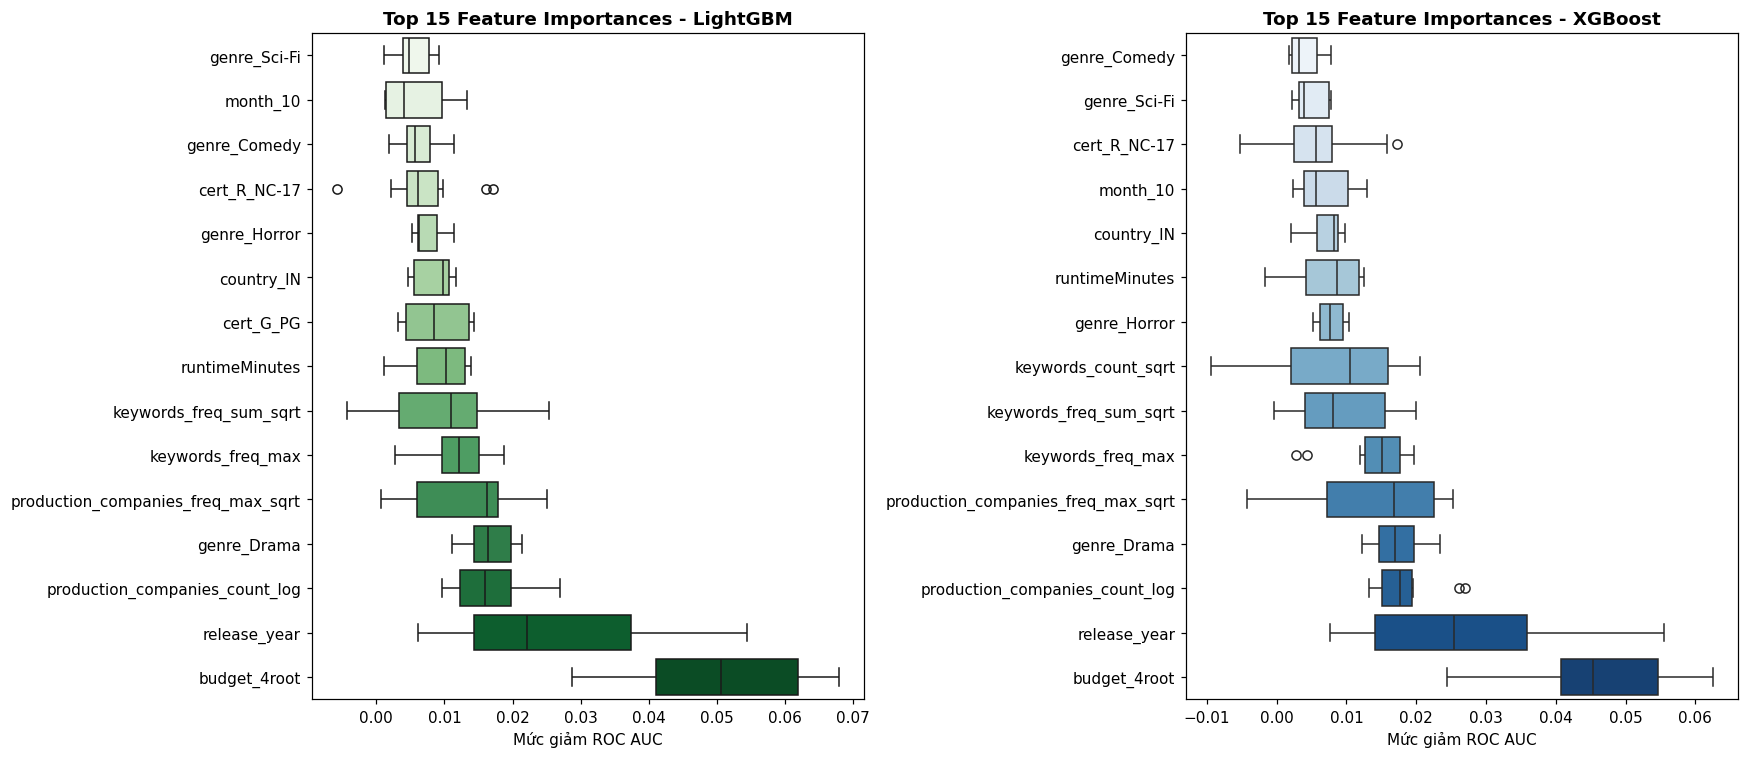

In [4]:
pi_lgb = permutation_importance(best_lgb, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1)
pi_xgb = permutation_importance(best_xgb, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1)

top_n = 15
sorted_idx_lgb = pi_lgb.importances_mean.argsort()[-top_n:]
sorted_idx_xgb = pi_xgb.importances_mean.argsort()[-top_n:]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=110)

sns.boxplot(data=pi_lgb.importances[sorted_idx_lgb].T, orient="h", ax=axes[0], palette="Greens")
axes[0].set_yticklabels(X_test.columns[sorted_idx_lgb])
axes[0].set_title(f"Top {top_n} Feature Importances - LightGBM", fontweight='bold')
axes[0].set_xlabel("Mức giảm ROC AUC")

sns.boxplot(data=pi_xgb.importances[sorted_idx_xgb].T, orient="h", ax=axes[1], palette="Blues")
axes[1].set_yticklabels(X_test.columns[sorted_idx_xgb])
axes[1].set_title(f"Top {top_n} Feature Importances - XGBoost", fontweight='bold')
axes[1].set_xlabel("Mức giảm ROC AUC")

plt.tight_layout()
plt.show()